In [8]:
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

# Add the project root to Python path (works from nested notebook folders)
_start_path = Path(__file__).resolve() if '__file__' in globals() else Path.cwd().resolve()
project_root = next((p for p in [_start_path, *_start_path.parents] if (p / 'ml_toolbox').exists()), None)
if project_root is None:
    raise RuntimeError('Could not locate project root containing ml_toolbox.')
sys.path.append(str(project_root))

from ml_toolbox.data_loader import create_label_to_class_map

saved_models_dir = project_root / "notebooks" / "test_output" / "history"
model_folders = [
    "fixed features both",
    "fixed features ch1ch2",
    "fixed features ch3ch4",
]
model_caches = [
    "3f2791ce70d3758616afc8811c364deed3c2e3af97067aa2f50330efa0200460",
    "6505c1fa4f35b06088195196060cd12c4dbb0d621fa527632717028659e6d8ad",
    "48f1e4ace9af9594e418446a820cb1711d5dc82a714af62ba1829cd5df920635",
]

if len(model_folders) != len(model_caches):
    raise ValueError("model_folders and model_caches must have equal length")


def _window_identity(meta: dict) -> tuple:
    """Stable identity for one window row to validate cross-model alignment."""
    return (
        str(meta.get("sample_id", "")),
        str(meta.get("path", meta.get("absolute_path", ""))),
        str(meta.get("window_id", "")),
        int(meta.get("start_sample", -1)),
        int(meta.get("end_sample", -1)),
    )


def _validate_fold_coverage(shap_res: dict, n_samples: int) -> None:
    folds = list(shap_res.get("shap_values_per_fold", []))
    if len(folds) == 0:
        raise ValueError("shap_res['shap_values_per_fold'] is empty")

    covered = np.zeros(n_samples, dtype=np.int32)
    for fold_idx, fold in enumerate(folds):
        val_idx = np.asarray(fold["val_idx"], dtype=np.int32)
        if val_idx.ndim != 1:
            raise ValueError(f"Fold {fold_idx}: val_idx must be 1D, got shape={val_idx.shape}")
        if val_idx.size == 0:
            raise ValueError(f"Fold {fold_idx}: val_idx is empty")
        if val_idx.min() < 0 or val_idx.max() >= n_samples:
            raise ValueError(
                f"Fold {fold_idx}: val_idx out of bounds [{val_idx.min()}, {val_idx.max()}] for n={n_samples}"
            )
        covered[val_idx] += 1

    if np.any(covered == 0):
        missing_count = int(np.sum(covered == 0))
        raise ValueError(f"Some rows are not covered by validation folds: missing={missing_count}")
    if np.any(covered > 1):
        overlap_count = int(np.sum(covered > 1))
        raise ValueError(f"Some rows appear in multiple validation folds: overlaps={overlap_count}")


def _reconstruct_oof(shap_res: dict, features: np.ndarray, global_class_order: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Reconstruct OOF hard predictions + class probabilities from fold estimators."""
    estimators = list(shap_res.get("estimators", []))
    if len(estimators) == 0:
        raise ValueError("shap_res does not contain estimators needed for OOF reconstruction")

    n_samples = features.shape[0]
    n_classes = len(global_class_order)

    y_pred_oof = np.empty(n_samples, dtype=np.int32)
    y_pred_oof.fill(-999999)
    y_proba_oof = np.full((n_samples, n_classes), np.nan, dtype=np.float64)
    seen = np.zeros(n_samples, dtype=np.int32)

    class_to_col = {int(c): idx for idx, c in enumerate(global_class_order)}

    for fold_idx, (estimator, val_idx) in enumerate(estimators):
        val_idx = np.asarray(val_idx, dtype=np.int32)
        X_val = features[val_idx]

        fold_pred = np.asarray(estimator.predict(X_val), dtype=np.int32)
        fold_proba = np.asarray(estimator.predict_proba(X_val), dtype=np.float64)
        est_classes = np.asarray(estimator.classes_, dtype=np.int32)

        if fold_pred.shape[0] != val_idx.shape[0]:
            raise ValueError(
                f"Fold {fold_idx}: predicted rows ({fold_pred.shape[0]}) != val_idx rows ({val_idx.shape[0]})"
            )
        if fold_proba.shape[0] != val_idx.shape[0]:
            raise ValueError(
                f"Fold {fold_idx}: proba rows ({fold_proba.shape[0]}) != val_idx rows ({val_idx.shape[0]})"
            )

        y_pred_oof[val_idx] = fold_pred

        for est_col_idx, class_label in enumerate(est_classes):
            class_label = int(class_label)
            if class_label not in class_to_col:
                raise ValueError(
                    f"Fold {fold_idx}: estimator class {class_label} not in global class order {global_class_order.tolist()}"
                )
            global_col_idx = class_to_col[class_label]
            y_proba_oof[val_idx, global_col_idx] = fold_proba[:, est_col_idx]

        seen[val_idx] += 1

    if np.any(seen == 0):
        missing = int(np.sum(seen == 0))
        raise ValueError(f"OOF reconstruction missing predictions for {missing} rows")
    if np.any(seen > 1):
        dup = int(np.sum(seen > 1))
        raise ValueError(f"OOF reconstruction wrote multiple predictions for {dup} rows")
    if np.any(np.isnan(y_proba_oof)):
        nan_count = int(np.isnan(y_proba_oof).sum())
        raise ValueError(f"OOF probability matrix still has NaN values: {nan_count}")

    return y_pred_oof, y_proba_oof


artifact_store: dict[str, dict] = {}
rows = []

for model_folder, cache_key in zip(model_folders, model_caches):
    run_dir = saved_models_dir / model_folder
    bundle_cache_path = run_dir / f"bundle_{cache_key}.joblib"
    eval_cache_path = run_dir / f"eval_res_{cache_key}.joblib"
    shap_cache_path = run_dir / f"shap_res_{cache_key}.joblib"

    bundle = joblib.load(bundle_cache_path)
    eval_res = joblib.load(eval_cache_path)
    shap_res = joblib.load(shap_cache_path)

    labels = np.asarray(bundle["labels"], dtype=np.int32)
    features = np.asarray(bundle["features"])
    feature_names = list(bundle["feature_names"])
    win_metadata = list(bundle["win_metadata"])

    if labels.shape[0] != features.shape[0] or labels.shape[0] != len(win_metadata):
        raise ValueError(
            f"Row mismatch in '{model_folder}': labels={labels.shape[0]}, features={features.shape[0]}, win_metadata={len(win_metadata)}"
        )

    _validate_fold_coverage(shap_res=shap_res, n_samples=labels.shape[0])

    unique_labels = np.asarray(eval_res.get("unique_labels", np.unique(labels)), dtype=np.int32)
    if unique_labels.ndim != 1:
        raise ValueError(f"unique_labels must be 1D, got shape={unique_labels.shape}")

    y_pred_oof, y_proba_oof = _reconstruct_oof(
        shap_res=shap_res,
        features=features,
        global_class_order=unique_labels,
    )

    label_to_class = create_label_to_class_map(win_metadata)
    class_names = [label_to_class.get(int(lbl), f"Class {int(lbl)}") for lbl in unique_labels]

    artifact_store[model_folder] = {
        "cache_key": cache_key,
        "bundle": bundle,
        "eval_res": eval_res,
        "shap_res": shap_res,
        "labels": labels,
        "features": features,
        "feature_names": feature_names,
        "win_metadata": win_metadata,
        "window_identity": [_window_identity(m) for m in win_metadata],
        "unique_labels": unique_labels,
        "class_names": class_names,
        "y_pred_oof": y_pred_oof,
        "y_proba_oof": y_proba_oof,
    }

    rows.append({
        "model_folder": model_folder,
        "n_samples": int(labels.shape[0]),
        "n_features": int(features.shape[1]),
        "n_classes": int(unique_labels.shape[0]),
        "cv_folds": int(len(shap_res.get("shap_values_per_fold", []))),
        "has_estimators": bool(len(shap_res.get("estimators", [])) > 0),
        "mean_accuracy(eval_res)": float(eval_res.get("mean_accuracy", np.nan)),
        "oof_accuracy(reconstructed)": float(np.mean(y_pred_oof == labels)),
    })

# Cross-model alignment checks
ref_model = model_folders[0]
ref_labels = artifact_store[ref_model]["labels"]
ref_identity = artifact_store[ref_model]["window_identity"]
ref_unique_labels = artifact_store[ref_model]["unique_labels"]

for model_folder in model_folders[1:]:
    model_data = artifact_store[model_folder]

    if not np.array_equal(model_data["labels"], ref_labels):
        raise ValueError(f"Label array mismatch between '{ref_model}' and '{model_folder}'")
    if model_data["window_identity"] != ref_identity:
        raise ValueError(f"Window identity order mismatch between '{ref_model}' and '{model_folder}'")
    if not np.array_equal(model_data["unique_labels"], ref_unique_labels):
        raise ValueError(f"unique_labels mismatch between '{ref_model}' and '{model_folder}'")

summary_df = pd.DataFrame(rows)
print("Loaded all model artifacts and reconstructed OOF predictions/probabilities.")
display(summary_df)

Loaded all model artifacts and reconstructed OOF predictions/probabilities.


,model_folder,n_samples,n_features,n_classes,cv_folds,has_estimators,mean_accuracy(eval_res),oof_accuracy(reconstructed)
0,fixed features both,19900,40,4,5,True,0.894953,0.895578
1,fixed features ch1ch2,19900,20,4,5,True,0.879428,0.880000
2,fixed features ch3ch4,19900,20,4,5,True,0.891788,0.892513


In [9]:
# SHAP sensor-group importance as percentages (overall + per-class + macro over classes)

import numpy as np
import pandas as pd

if "artifact_store" not in globals() or len(artifact_store) == 0:
    raise RuntimeError("artifact_store is not available. Run Cell 1 first.")

group_columns = [
    "ch1",
    "ch2",
    "ch3",
    "ch4",
    "ch1ch2",
    "ch3ch4",
    "speed",
    "load",
    "speed_load",
]

def _as_n_s_c_f(
    fold_shap_values: object,
    expected_n_features: int,
    expected_n_samples: int | None = None,
) -> np.ndarray:
    """Normalize fold SHAP values to shape (n_samples, n_classes, n_features)."""
    if isinstance(fold_shap_values, list):
        if len(fold_shap_values) == 0:
            raise ValueError("Received empty list for fold SHAP values")
        arr_list = [np.asarray(x, dtype=np.float64) for x in fold_shap_values]
        first_shape = arr_list[0].shape
        if len(first_shape) != 2:
            raise ValueError(f"Expected class SHAP matrix with 2 dims, got {first_shape}")
        n_samples, n_features = first_shape
        if n_features != expected_n_features:
            raise ValueError(
                f"List SHAP n_features={n_features} does not match expected={expected_n_features}"
            )
        for idx, arr in enumerate(arr_list):
            if arr.shape != first_shape:
                raise ValueError(
                    f"Inconsistent class SHAP shape in list at idx {idx}: {arr.shape} vs {first_shape}"
                )
        return np.stack(arr_list, axis=1)

    arr = np.asarray(fold_shap_values, dtype=np.float64)
    if arr.ndim == 2:
        n_samples, n_features = arr.shape
        if n_features != expected_n_features:
            raise ValueError(
                f"2D SHAP n_features={n_features} does not match expected={expected_n_features}"
            )
        return arr.reshape(n_samples, 1, n_features)

    if arr.ndim == 3:
        d0, d1, d2 = arr.shape
        feature_axis_candidates = [i for i, d in enumerate((d0, d1, d2)) if d == expected_n_features]
        if len(feature_axis_candidates) == 0:
            raise ValueError(
                f"3D SHAP shape {arr.shape} has no axis matching expected_n_features={expected_n_features}"
            )

        if 2 in feature_axis_candidates:
            feature_axis = 2
        else:
            feature_axis = feature_axis_candidates[0]

        arr_f_last = np.moveaxis(arr, feature_axis, -1)  # (?, ?, n_features)
        a, b, _ = arr_f_last.shape

        if expected_n_samples is not None and expected_n_samples in (a, b):
            sample_axis = 0 if a == expected_n_samples else 1
        else:
            sample_axis = 0 if a >= b else 1

        if sample_axis == 0:
            return arr_f_last
        return np.transpose(arr_f_last, (1, 0, 2))

    raise ValueError(f"Unsupported SHAP array layout with shape {arr.shape}")

def _group_indices(feature_names: list[str]) -> dict[str, list[int]]:
    ch1 = [i for i, n in enumerate(feature_names) if n.startswith("ch1_")]
    ch2 = [i for i, n in enumerate(feature_names) if n.startswith("ch2_")]
    ch3 = [i for i, n in enumerate(feature_names) if n.startswith("ch3_")]
    ch4 = [i for i, n in enumerate(feature_names) if n.startswith("ch4_")]

    speed = [i for i, n in enumerate(feature_names) if n in {"electrical_frequency_hz", "frequency_hz"}]
    load = [i for i, n in enumerate(feature_names) if n == "load"]
    speed_load = sorted(set(speed + load))

    return {
        "ch1": ch1,
        "ch2": ch2,
        "ch3": ch3,
        "ch4": ch4,
        "ch1ch2": ch1 + ch2,
        "ch3ch4": ch3 + ch4,
        "speed": speed,
        "load": load,
        "speed_load": speed_load,
    }

def _aggregate_groups(mean_abs_per_feature: np.ndarray, groups: dict[str, list[int]]) -> dict[str, float]:
    out = {}
    for group_name in group_columns:
        idx = groups[group_name]
        if len(idx) == 0:
            out[group_name] = np.nan
        else:
            out[group_name] = float(np.sum(mean_abs_per_feature[idx]))
    return out

def _to_percent(group_scores: dict[str, float], denom: float) -> dict[str, float]:
    out = {}
    for group_name in group_columns:
        val = group_scores[group_name]
        if np.isnan(val) or not np.isfinite(denom) or denom <= 0.0:
            out[group_name] = np.nan
        else:
            out[group_name] = float(100.0 * val / denom)
    return out

overall_rows = []
overall_pct_rows = []
per_class_rows = []
per_class_pct_rows = []

for model_folder in model_folders:
    model_data = artifact_store[model_folder]
    shap_res = model_data["shap_res"]
    feature_names = list(model_data["feature_names"])
    class_names = list(model_data["class_names"])
    unique_labels = np.asarray(model_data["unique_labels"], dtype=np.int32)

    folds = list(shap_res.get("shap_values_per_fold", []))
    if len(folds) == 0:
        raise ValueError(f"{model_folder}: shap_values_per_fold is empty")

    groups = _group_indices(feature_names)
    if sum(len(v) for v in groups.values()) == 0:
        raise ValueError(f"{model_folder}: none of requested groups found in feature_names")

    fold_arrays = []
    for fold_idx, fold in enumerate(folds):
        val_idx = np.asarray(fold.get("val_idx", []), dtype=np.int32)
        expected_n_samples = int(val_idx.shape[0]) if val_idx.ndim == 1 else None
        fold_arr = _as_n_s_c_f(
            fold["shap_values"],
            expected_n_features=len(feature_names),
            expected_n_samples=expected_n_samples,
        )
        if fold_arr.shape[2] != len(feature_names):
            raise ValueError(
                f"{model_folder} fold {fold_idx}: SHAP n_features={fold_arr.shape[2]} != feature_names={len(feature_names)}"
            )
        if expected_n_samples is not None and fold_arr.shape[0] != expected_n_samples:
            raise ValueError(
                f"{model_folder} fold {fold_idx}: SHAP n_samples={fold_arr.shape[0]} != val_idx n_samples={expected_n_samples}"
            )
        fold_arrays.append(fold_arr)

    all_shap = np.concatenate(fold_arrays, axis=0)  # (n_samples_total, n_classes, n_features)
    n_classes_shap = all_shap.shape[1]

    overall_mean_abs = np.mean(np.abs(all_shap), axis=(0, 1))
    overall_total_abs = float(np.sum(overall_mean_abs))
    overall_group_scores = _aggregate_groups(overall_mean_abs, groups)
    overall_rows.append({
        "model_folder": model_folder,
        **overall_group_scores,
    })
    overall_pct_rows.append({
        "model_folder": model_folder,
        **_to_percent(overall_group_scores, overall_total_abs),
    })

    n_classes_to_use = min(len(unique_labels), len(class_names), n_classes_shap)
    for class_idx in range(n_classes_to_use):
        class_mean_abs = np.mean(np.abs(all_shap[:, class_idx, :]), axis=0)
        class_total_abs = float(np.sum(class_mean_abs))
        class_group_scores = _aggregate_groups(class_mean_abs, groups)

        row_base = {
            "model_folder": model_folder,
            "class_label": int(unique_labels[class_idx]),
            "class_name": str(class_names[class_idx]),
        }

        per_class_rows.append({
            **row_base,
            **class_group_scores,
        })
        per_class_pct_rows.append({
            **row_base,
            **_to_percent(class_group_scores, class_total_abs),
        })

overall_group_importance_df = pd.DataFrame(overall_rows)
overall_group_importance_pct_df = pd.DataFrame(overall_pct_rows)
per_class_group_importance_df = pd.DataFrame(per_class_rows)
per_class_group_importance_pct_df = pd.DataFrame(per_class_pct_rows)

macro_group_importance_df = (
    per_class_group_importance_df
    .groupby("model_folder", observed=False)[group_columns]
    .mean()
    .reset_index()
)
macro_group_importance_pct_df = (
    per_class_group_importance_pct_df
    .groupby("model_folder", observed=False)[group_columns]
    .mean()
    .reset_index()
)

ordered_overall_cols = ["model_folder", *group_columns]
ordered_per_class_cols = ["model_folder", "class_label", "class_name", *group_columns]

overall_group_importance_df = overall_group_importance_df[ordered_overall_cols]
overall_group_importance_pct_df = overall_group_importance_pct_df[ordered_overall_cols]
per_class_group_importance_df = per_class_group_importance_df[ordered_per_class_cols]
per_class_group_importance_pct_df = per_class_group_importance_pct_df[ordered_per_class_cols]
macro_group_importance_df = macro_group_importance_df[["model_folder", *group_columns]]
macro_group_importance_pct_df = macro_group_importance_pct_df[["model_folder", *group_columns]]

print("SHAP sensor-group importance as percentage of total mean absolute SHAP per row.")
print("Note: groups overlap (e.g., ch1 + ch2 contributes to ch1ch2, speed/load contributes to speed_load),")
print("so percentages across all shown columns are not expected to sum to 100%.")

print("\nOverall (%) (all samples, macro over classes):")
display(overall_group_importance_pct_df.round(3))

print("\nPer-class (%):")
display(per_class_group_importance_pct_df.round(3))

print("\nMacro over classes (%) (equal class weight):")
display(macro_group_importance_pct_df.round(3))

SHAP sensor-group importance as percentage of total mean absolute SHAP per row.
Note: groups overlap (e.g., ch1 + ch2 contributes to ch1ch2, speed/load contributes to speed_load),
so percentages across all shown columns are not expected to sum to 100%.

Overall (%) (all samples, macro over classes):


,model_folder,ch1,ch2,ch3,ch4,ch1ch2,ch3ch4,speed,load,speed_load
0,fixed features both,24.232,24.856,24.773,26.139,49.088,50.912,NaN,NaN,NaN
1,fixed features ch1ch2,49.821,50.179,NaN,NaN,100.000,NaN,NaN,NaN,NaN
2,fixed features ch3ch4,NaN,NaN,48.436,51.564,NaN,100.000,NaN,NaN,NaN



Per-class (%):


,model_folder,class_label,class_name,ch1,ch2,ch3,ch4,ch1ch2,ch3ch4,speed,load,speed_load
0,fixed features both,0,d0,25.159,26.429,22.721,25.691,51.588,48.412,NaN,NaN,NaN
1,fixed features both,1,d3,20.714,26.185,27.593,25.508,46.898,53.102,NaN,NaN,NaN
2,fixed features both,2,d6,27.061,23.291,23.031,26.616,50.353,49.647,NaN,NaN,NaN
3,fixed features both,3,d9,23.922,23.744,25.674,26.661,47.666,52.334,NaN,NaN,NaN
4,fixed features ch1ch2,0,d0,49.000,51.000,NaN,NaN,100.000,NaN,NaN,NaN,NaN
5,fixed features ch1ch2,1,d3,46.560,53.440,NaN,NaN,100.000,NaN,NaN,NaN,NaN
6,fixed features ch1ch2,2,d6,53.188,46.812,NaN,NaN,100.000,NaN,NaN,NaN,NaN
7,fixed features ch1ch2,3,d9,50.134,49.866,NaN,NaN,100.000,NaN,NaN,NaN,NaN
8,fixed features ch3ch4,0,d0,NaN,NaN,48.095,51.905,NaN,100.000,NaN,NaN,NaN
9,fixed features ch3ch4,1,d3,NaN,NaN,51.647,48.353,NaN,100.000,NaN,NaN,NaN



Macro over classes (%) (equal class weight):


,model_folder,ch1,ch2,ch3,ch4,ch1ch2,ch3ch4,speed,load,speed_load
0,fixed features both,24.214,24.912,24.755,26.119,49.126,50.874,NaN,NaN,NaN
1,fixed features ch1ch2,49.720,50.280,NaN,NaN,100.000,NaN,NaN,NaN,NaN
2,fixed features ch3ch4,NaN,NaN,48.457,51.543,NaN,100.000,NaN,NaN,NaN


In [10]:
# Pairwise overlap categories using reconstructed OOF predictions

from itertools import combinations

overlap_rows = []

for sensor1, sensor2 in combinations(model_folders, 2):
    y_true = artifact_store[sensor1]["labels"]
    pred1 = artifact_store[sensor1]["y_pred_oof"]
    pred2 = artifact_store[sensor2]["y_pred_oof"]

    if not np.array_equal(y_true, artifact_store[sensor2]["labels"]):
        raise ValueError(f"Cannot compare '{sensor1}' and '{sensor2}': label mismatch")

    s1_correct = pred1 == y_true
    s2_correct = pred2 == y_true

    both_correct = int(np.sum(s1_correct & s2_correct))
    sensor1_only_correct = int(np.sum(s1_correct & (~s2_correct)))
    sensor2_only_correct = int(np.sum((~s1_correct) & s2_correct))
    both_wrong = int(np.sum((~s1_correct) & (~s2_correct)))

    total = int(y_true.shape[0])
    if both_correct + sensor1_only_correct + sensor2_only_correct + both_wrong != total:
        raise RuntimeError("Overlap category counts do not sum to total samples")

    overlap_rows.extend([
        {
            "sensor1": sensor1,
            "sensor2": sensor2,
            "category": "both_correct",
            "count": both_correct,
            "ratio": both_correct / total,
        },
        {
            "sensor1": sensor1,
            "sensor2": sensor2,
            "category": "sensor1_only_correct",
            "count": sensor1_only_correct,
            "ratio": sensor1_only_correct / total,
        },
        {
            "sensor1": sensor1,
            "sensor2": sensor2,
            "category": "sensor2_only_correct",
            "count": sensor2_only_correct,
            "ratio": sensor2_only_correct / total,
        },
        {
            "sensor1": sensor1,
            "sensor2": sensor2,
            "category": "both_wrong",
            "count": both_wrong,
            "ratio": both_wrong / total,
        },
    ])

overlap_df = pd.DataFrame(overlap_rows)
print("Pairwise error-overlap categories:")
display(overlap_df)

print("\nPivot view (counts):")
display(
    overlap_df.pivot_table(
        index=["sensor1", "sensor2"],
        columns="category",
        values="count",
        aggfunc="sum",
    ).reset_index()
)

Pairwise error-overlap categories:


,sensor1,sensor2,category,count,ratio
0,fixed features both,fixed features ch1ch2,both_correct,17019,0.855226
1,fixed features both,fixed features ch1ch2,sensor1_only_correct,803,0.040352
2,fixed features both,fixed features ch1ch2,sensor2_only_correct,493,0.024774
3,fixed features both,fixed features ch1ch2,both_wrong,1585,0.079648
4,fixed features both,fixed features ch3ch4,both_correct,17102,0.859397
5,fixed features both,fixed features ch3ch4,sensor1_only_correct,720,0.036181
6,fixed features both,fixed features ch3ch4,sensor2_only_correct,659,0.033116
7,fixed features both,fixed features ch3ch4,both_wrong,1419,0.071307
8,fixed features ch1ch2,fixed features ch3ch4,both_correct,16438,0.826030
9,fixed features ch1ch2,fixed features ch3ch4,sensor1_only_correct,1074,0.053970



Pivot view (counts):


category,sensor1,sensor2,both_correct,both_wrong,sensor1_only_correct,sensor2_only_correct
0,fixed features both,fixed features ch1ch2,17019,1585,803,493
1,fixed features both,fixed features ch3ch4,17102,1419,720,659
2,fixed features ch1ch2,fixed features ch3ch4,16438,1065,1074,1323


In [11]:
# Multiclass ROC-AUC (One-vs-Rest), including per-class AUC

from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

roc_rows = []

for model_folder in model_folders:
    model_data = artifact_store[model_folder]
    y_true = model_data["labels"]
    y_proba = model_data["y_proba_oof"]
    unique_labels = np.asarray(model_data["unique_labels"], dtype=np.int32)
    class_names = list(model_data["class_names"])

    if y_proba.shape[0] != y_true.shape[0]:
        raise ValueError(
            f"{model_folder}: probability rows {y_proba.shape[0]} != labels {y_true.shape[0]}"
        )
    if y_proba.shape[1] != unique_labels.shape[0]:
        raise ValueError(
            f"{model_folder}: probability cols {y_proba.shape[1]} != classes {unique_labels.shape[0]}"
        )

    row_sums = np.sum(y_proba, axis=1)
    if not np.all(np.isfinite(row_sums)):
        raise ValueError(f"{model_folder}: non-finite values in probability matrix")
    if not np.allclose(row_sums, 1.0, atol=1e-6):
        max_dev = float(np.max(np.abs(row_sums - 1.0)))
        print(f"Warning: {model_folder} probability row sums deviate from 1.0 (max dev={max_dev:.2e})")

    y_true_bin = label_binarize(y_true, classes=unique_labels)

    auc_macro = roc_auc_score(y_true_bin, y_proba, average="macro", multi_class="ovr")
    auc_weighted = roc_auc_score(y_true_bin, y_proba, average="weighted", multi_class="ovr")

    roc_rows.append({
        "model_folder": model_folder,
        "scope": "overall",
        "class_label": "macro_ovr",
        "class_name": "macro_ovr",
        "roc_auc": float(auc_macro),
    })
    roc_rows.append({
        "model_folder": model_folder,
        "scope": "overall",
        "class_label": "weighted_ovr",
        "class_name": "weighted_ovr",
        "roc_auc": float(auc_weighted),
    })

    for class_col, class_label in enumerate(unique_labels):
        y_true_one_vs_rest = y_true_bin[:, class_col]
        if np.unique(y_true_one_vs_rest).size < 2:
            auc_val = np.nan
        else:
            auc_val = roc_auc_score(y_true_one_vs_rest, y_proba[:, class_col])

        roc_rows.append({
            "model_folder": model_folder,
            "scope": "per_class",
            "class_label": int(class_label),
            "class_name": class_names[class_col],
            "roc_auc": float(auc_val) if np.isfinite(auc_val) else np.nan,
        })

roc_auc_df = pd.DataFrame(roc_rows)
print("ROC-AUC OvR summary:")
display(roc_auc_df)

print("\nPer-class pivot table:")
display(
    roc_auc_df[roc_auc_df["scope"] == "per_class"]
    .pivot_table(index="model_folder", columns="class_name", values="roc_auc", aggfunc="mean")
    .reset_index()
)

ROC-AUC OvR summary:


,model_folder,scope,class_label,class_name,roc_auc
0,fixed features both,overall,macro_ovr,macro_ovr,0.981441
1,fixed features both,overall,weighted_ovr,weighted_ovr,0.981441
2,fixed features both,per_class,0,d0,0.978677
3,fixed features both,per_class,1,d3,0.949920
4,fixed features both,per_class,2,d6,0.997913
5,fixed features both,per_class,3,d9,0.999254
6,fixed features ch1ch2,overall,macro_ovr,macro_ovr,0.979836
7,fixed features ch1ch2,overall,weighted_ovr,weighted_ovr,0.979836
8,fixed features ch1ch2,per_class,0,d0,0.975752
9,fixed features ch1ch2,per_class,1,d3,0.951659



Per-class pivot table:


class_name,model_folder,d0,d3,d6,d9
0,fixed features both,0.978677,0.949920,0.997913,0.999254
1,fixed features ch1ch2,0.975752,0.951659,0.994998,0.996934
2,fixed features ch3ch4,0.977826,0.951916,0.997738,0.999294


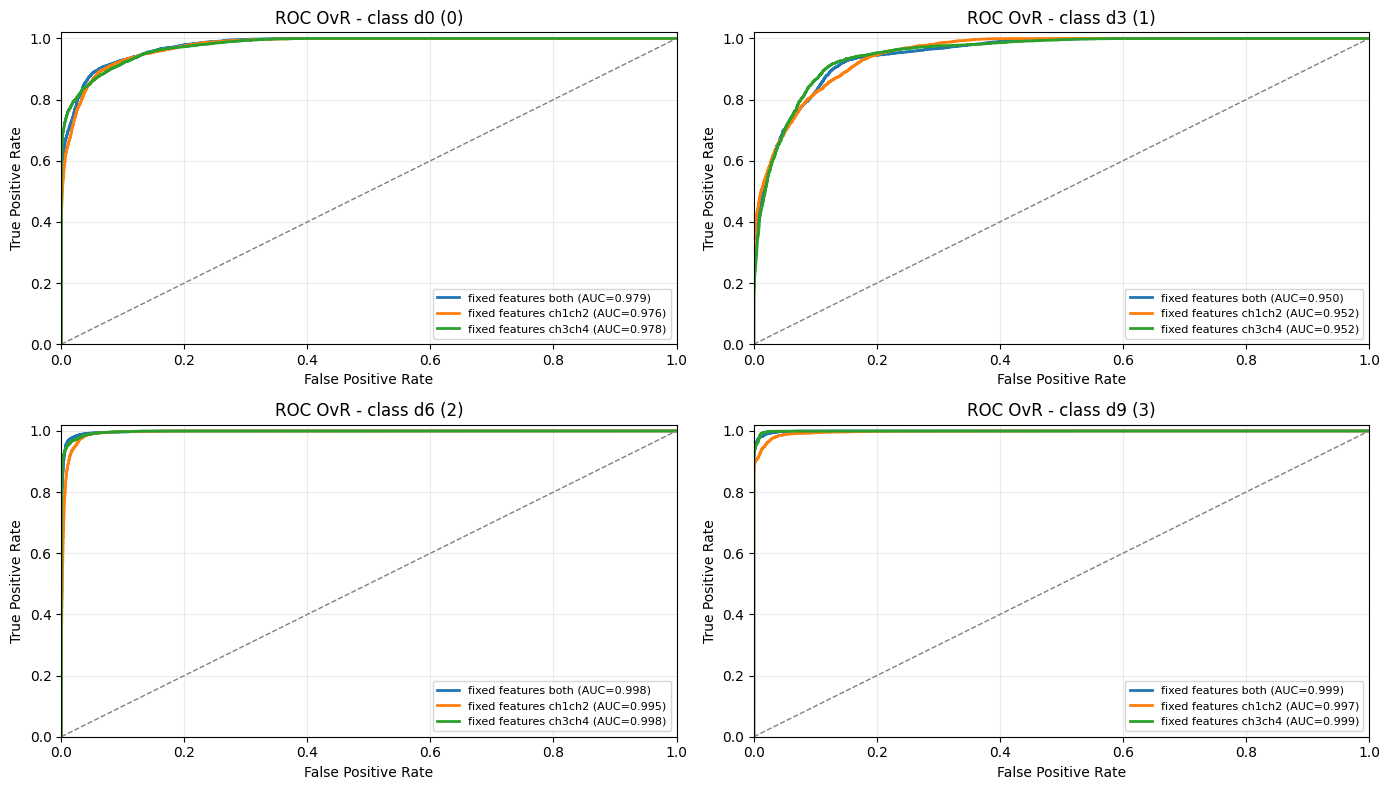

In [12]:
# ROC curves: per class, per model (One-vs-Rest)

import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

n_models = len(model_folders)
ref_unique_labels = np.asarray(artifact_store[model_folders[0]]["unique_labels"], dtype=np.int32)
ref_class_names = list(artifact_store[model_folders[0]]["class_names"])

n_classes = len(ref_unique_labels)
n_cols = 2
n_rows = int(math.ceil(n_classes / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows), squeeze=False)

for class_idx, class_label in enumerate(ref_unique_labels):
    r = class_idx // n_cols
    c = class_idx % n_cols
    ax = axes[r, c]

    for model_folder in model_folders:
        model_data = artifact_store[model_folder]
        y_true = np.asarray(model_data["labels"], dtype=np.int32)
        y_proba = np.asarray(model_data["y_proba_oof"], dtype=float)
        unique_labels = np.asarray(model_data["unique_labels"], dtype=np.int32)

        if not np.array_equal(unique_labels, ref_unique_labels):
            raise ValueError(
                f"Class order mismatch: '{model_folder}' has {unique_labels.tolist()}, expected {ref_unique_labels.tolist()}"
            )

        y_true_bin = label_binarize(y_true, classes=unique_labels)[:, class_idx]
        y_score = y_proba[:, class_idx]

        if np.unique(y_true_bin).size < 2:
            continue

        fpr, tpr, _ = roc_curve(y_true_bin, y_score)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, label=f"{model_folder} (AUC={roc_auc:.3f})")

    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1)
    ax.set_title(f"ROC OvR - class {ref_class_names[class_idx]} ({int(class_label)})")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.02)
    ax.grid(alpha=0.25)
    ax.legend(loc="lower right", fontsize=8)

# Hide any unused subplot axes
for idx in range(n_classes, n_rows * n_cols):
    r = idx // n_cols
    c = idx % n_cols
    axes[r, c].axis("off")

plt.tight_layout()
plt.show()

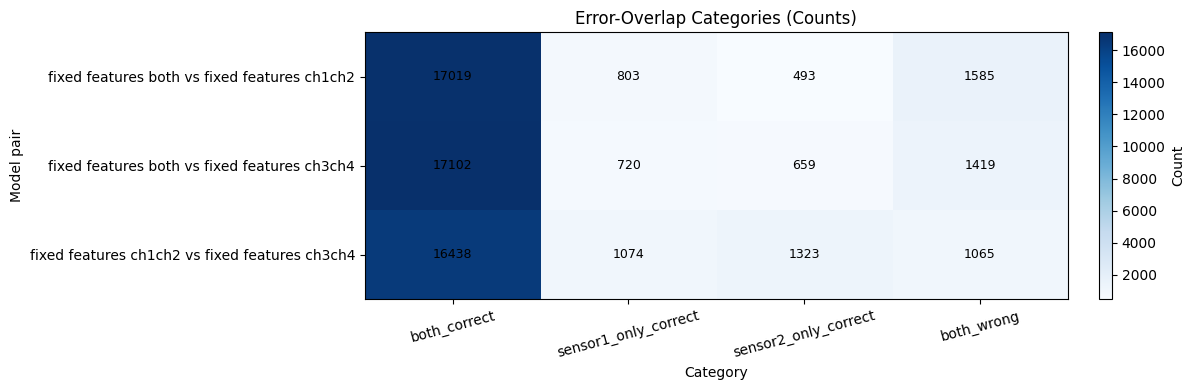

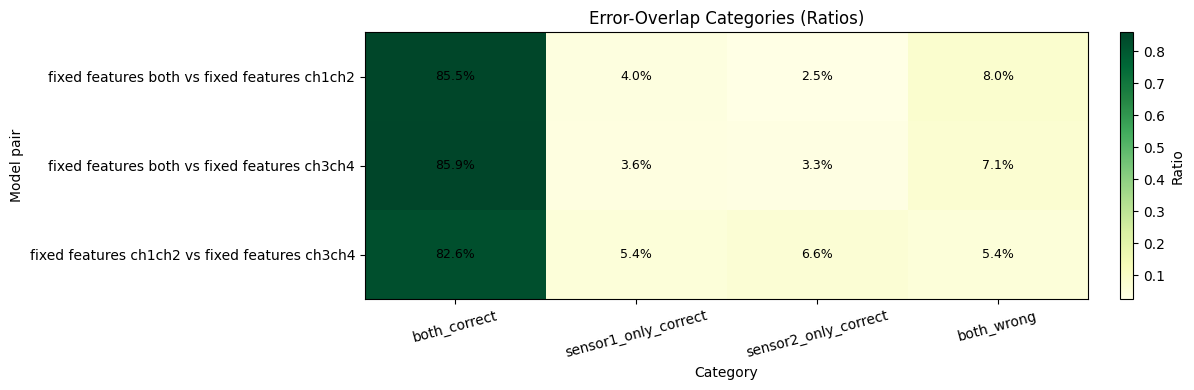

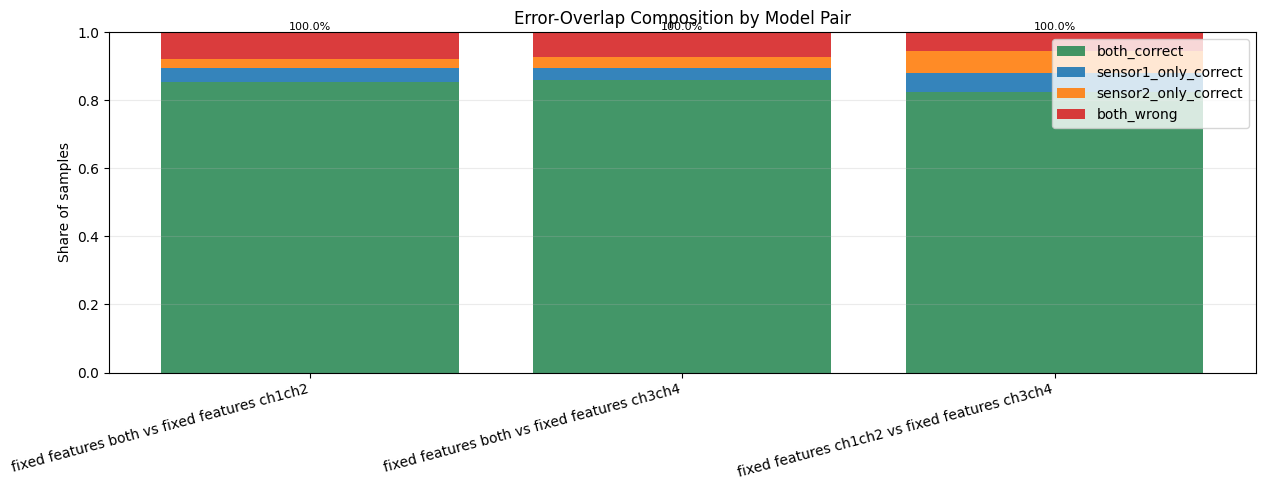

In [13]:
# Overlap visualizations: heatmaps + stacked bar chart

import numpy as np
import matplotlib.pyplot as plt

required_categories = [
    "both_correct",
    "sensor1_only_correct",
    "sensor2_only_correct",
    "both_wrong",
]

overlap_counts = (
    overlap_df.pivot_table(
        index=["sensor1", "sensor2"],
        columns="category",
        values="count",
        aggfunc="sum",
    )
    .reindex(columns=required_categories)
    .fillna(0)
)
overlap_ratios = (
    overlap_df.pivot_table(
        index=["sensor1", "sensor2"],
        columns="category",
        values="ratio",
        aggfunc="sum",
    )
    .reindex(columns=required_categories)
    .fillna(0.0)
)

pair_labels = [f"{a} vs {b}" for a, b in overlap_counts.index.to_list()]

# 1) Heatmap for counts
fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(overlap_counts.values, aspect="auto", cmap="Blues")
ax.set_title("Error-Overlap Categories (Counts)")
ax.set_xticks(np.arange(len(required_categories)))
ax.set_xticklabels(required_categories, rotation=15)
ax.set_yticks(np.arange(len(pair_labels)))
ax.set_yticklabels(pair_labels)
ax.set_xlabel("Category")
ax.set_ylabel("Model pair")

for i in range(overlap_counts.shape[0]):
    for j in range(overlap_counts.shape[1]):
        ax.text(j, i, f"{int(overlap_counts.values[i, j])}", ha="center", va="center", fontsize=9)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Count")
plt.tight_layout()
plt.show()

# 2) Heatmap for ratios
fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(overlap_ratios.values, aspect="auto", cmap="YlGn")
ax.set_title("Error-Overlap Categories (Ratios)")
ax.set_xticks(np.arange(len(required_categories)))
ax.set_xticklabels(required_categories, rotation=15)
ax.set_yticks(np.arange(len(pair_labels)))
ax.set_yticklabels(pair_labels)
ax.set_xlabel("Category")
ax.set_ylabel("Model pair")

for i in range(overlap_ratios.shape[0]):
    for j in range(overlap_ratios.shape[1]):
        ax.text(j, i, f"{overlap_ratios.values[i, j] * 100:.1f}%", ha="center", va="center", fontsize=9)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Ratio")
plt.tight_layout()
plt.show()

# 3) Stacked bar chart (ratios) for quick pairwise comparison
x = np.arange(len(pair_labels))
width = 0.8
bottom = np.zeros(len(pair_labels), dtype=float)

palette = {
    "both_correct": "#2E8B57",
    "sensor1_only_correct": "#1f77b4",
    "sensor2_only_correct": "#ff7f0e",
    "both_wrong": "#d62728",
}

fig, ax = plt.subplots(figsize=(13, 5))
for cat in required_categories:
    vals = overlap_ratios[cat].to_numpy(dtype=float)
    ax.bar(x, vals, width, bottom=bottom, label=cat, color=palette[cat], alpha=0.9)
    bottom += vals

ax.set_title("Error-Overlap Composition by Model Pair")
ax.set_xticks(x)
ax.set_xticklabels(pair_labels, rotation=15, ha="right")
ax.set_ylabel("Share of samples")
ax.set_ylim(0.0, 1.0)
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="upper right")

for i, total in enumerate(bottom):
    ax.text(i, min(total + 0.01, 1.0), f"{total * 100:.1f}%", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

In [14]:
# Disagreement diagnostics: class/speed/load composition for one sensor pair

import numpy as np
import pandas as pd

# Choose the pair to analyze deeply.
# This default matches the pair where both_wrong was 939 in your earlier output.
sensor1_model = "fixed features ch1ch2"
sensor2_model = "fixed features ch3ch4"

if sensor1_model not in artifact_store or sensor2_model not in artifact_store:
    raise ValueError("Selected sensor model names are not available in artifact_store")

m1 = artifact_store[sensor1_model]
m2 = artifact_store[sensor2_model]

if not np.array_equal(m1["labels"], m2["labels"]):
    raise ValueError("Label arrays mismatch between selected models")
if m1["window_identity"] != m2["window_identity"]:
    raise ValueError("Window identity mismatch between selected models")

labels = np.asarray(m1["labels"], dtype=np.int32)
pred1 = np.asarray(m1["y_pred_oof"], dtype=np.int32)
pred2 = np.asarray(m2["y_pred_oof"], dtype=np.int32)
meta = list(m1["win_metadata"])

if len(meta) != labels.shape[0]:
    raise ValueError("win_metadata length does not match labels")


def _extract_frequency_hz(row_meta: dict) -> float:
    """Read frequency from common metadata keys and normalize to numeric Hz."""
    raw = row_meta.get("electrical_frequency_hz", row_meta.get("frequency_hz", np.nan))

    if isinstance(raw, str):
        cleaned = raw.strip().lower().replace("hz", "")
        cleaned = cleaned.replace("_", "").replace(" ", "")
        raw = cleaned

    try:
        val = float(raw)
        return val if np.isfinite(val) else np.nan
    except (TypeError, ValueError):
        return np.nan


label_to_class = {int(k): str(v) for k, v in zip(m1["unique_labels"], m1["class_names"])}

s1_correct = pred1 == labels
s2_correct = pred2 == labels

mask_sensor1_only = s1_correct & (~s2_correct)
mask_sensor2_only = (~s1_correct) & s2_correct
mask_both_wrong = (~s1_correct) & (~s2_correct)

analysis_df = pd.DataFrame({
    "true_label": labels,
    "true_class": [label_to_class.get(int(y), f"Class {int(y)}") for y in labels],
    "sensor1_pred": pred1,
    "sensor2_pred": pred2,
    "sensor1_correct": s1_correct,
    "sensor2_correct": s2_correct,
    "electrical_frequency_hz": [_extract_frequency_hz(m) for m in meta],
    "load": [m.get("load", "unknown") for m in meta],
})

analysis_df["group"] = "both_correct"
analysis_df.loc[mask_sensor1_only, "group"] = "sensor1_only_correct"
analysis_df.loc[mask_sensor2_only, "group"] = "sensor2_only_correct"
analysis_df.loc[mask_both_wrong, "group"] = "both_wrong"

focus_groups = ["sensor1_only_correct", "sensor2_only_correct", "both_wrong"]

summary_counts = (
    analysis_df[analysis_df["group"].isin(focus_groups)]
    .groupby("group", observed=False)
    .size()
    .rename("count")
    .reset_index()
)
print(f"Analyzed pair: {sensor1_model} vs {sensor2_model}")
display(summary_counts)

# A) Which classes dominate disagreements?
print("\nA) True-class distribution in disagreement groups")
class_counts = (
    analysis_df[analysis_df["group"].isin(focus_groups)]
    .groupby(["group", "true_class"], observed=False)
    .size()
    .rename("count")
    .reset_index()
)
class_totals = class_counts.groupby("group", observed=False)["count"].transform("sum")
class_counts["ratio"] = class_counts["count"] / class_totals
class_counts = class_counts.sort_values(["group", "count"], ascending=[True, False]).reset_index(drop=True)
display(class_counts)

print("\nClass distribution pivot (%):")
display(
    class_counts.pivot_table(
        index="group",
        columns="true_class",
        values="ratio",
        aggfunc="sum",
    )
    .fillna(0.0)
    .round(4)
)

# B) Which speeds and loads produce disagreement?
print("\nB1) electrical_frequency_hz distribution by disagreement group")
focus_df = analysis_df[analysis_df["group"].isin(focus_groups)].copy()
focus_df["electrical_frequency_hz"] = pd.to_numeric(
    focus_df["electrical_frequency_hz"], errors="coerce"
)

all_speed_values = sorted(
    pd.to_numeric(analysis_df["electrical_frequency_hz"], errors="coerce")
    .dropna()
    .unique()
    .tolist()
)

if len(all_speed_values) == 0:
    raise ValueError("No valid electrical_frequency_hz values found in metadata")

freq_counts = (
    focus_df.groupby(["group", "electrical_frequency_hz"], observed=False, dropna=False)
    .size()
    .rename("count")
    .reindex(
        pd.MultiIndex.from_product(
            [focus_groups, all_speed_values], names=["group", "electrical_frequency_hz"]
        ),
        fill_value=0,
    )
    .reset_index()
)
freq_totals = freq_counts.groupby("group", observed=False)["count"].transform("sum")
freq_counts["ratio"] = np.where(freq_totals > 0, freq_counts["count"] / freq_totals, 0.0)
freq_counts = freq_counts.sort_values(["group", "electrical_frequency_hz"]).reset_index(drop=True)
display(freq_counts)

print("\nSpeed distribution pivot (%):")
display(
    freq_counts.pivot_table(
        index="group",
        columns="electrical_frequency_hz",
        values="ratio",
        aggfunc="sum",
    )
    .fillna(0.0)
    .round(4)
)

print("\nB2) load distribution by disagreement group")
load_counts = (
    analysis_df[analysis_df["group"].isin(focus_groups)]
    .groupby(["group", "load"], observed=False)
    .size()
    .rename("count")
    .reset_index()
)
load_totals = load_counts.groupby("group", observed=False)["count"].transform("sum")
load_counts["ratio"] = load_counts["count"] / load_totals
load_counts = load_counts.sort_values(["group", "count"], ascending=[True, False]).reset_index(drop=True)
display(load_counts)

print("\nLoad distribution pivot (%):")
display(
    load_counts.pivot_table(
        index="group",
        columns="load",
        values="ratio",
        aggfunc="sum",
    )
    .fillna(0.0)
    .round(4)
)

print("\nB3) speed x load x class combinations by outcome group (sorted by count)")
combo_group_order = ["both_correct", *focus_groups]
combo_counts = (
    analysis_df.groupby(
        ["group", "electrical_frequency_hz", "load", "true_class"],
        observed=False,
        dropna=False,
    )
    .size()
    .rename("count")
    .reset_index()
)
combo_totals = combo_counts.groupby("group", observed=False)["count"].transform("sum")
combo_counts["ratio"] = np.where(combo_totals > 0, combo_counts["count"] / combo_totals, 0.0)
combo_counts = (
    combo_counts[combo_counts["group"].isin(combo_group_order)]
    .sort_values(
        ["count", "group", "electrical_frequency_hz", "load", "true_class"],
        ascending=[False, True, True, True, True],
    )
    .reset_index(drop=True)
)
display(combo_counts)

# Explicit deep-dive for both_wrong slice (expected 939 for this pair)
both_wrong_df = analysis_df[analysis_df["group"] == "both_wrong"].copy()
print(f"\nBoth-wrong sample count: {len(both_wrong_df)}")

print("\nBoth-wrong: true class distribution")
display(
    both_wrong_df.groupby("true_class", observed=False)
    .size()
    .rename("count")
    .sort_values(ascending=False)
    .to_frame()
)

print("\nBoth-wrong: electrical_frequency_hz distribution")
display(
    both_wrong_df.groupby("electrical_frequency_hz", observed=False, dropna=False)
    .size()
    .rename("count")
    .sort_values(ascending=False)
    .to_frame()
)

print("\nBoth-wrong: load distribution")
display(
    both_wrong_df.groupby("load", observed=False)
    .size()
    .rename("count")
    .sort_values(ascending=False)
    .to_frame()
)

# Keep results accessible for later plotting/export
disagreement_analysis = {
    "pair": (sensor1_model, sensor2_model),
    "summary_counts": summary_counts,
    "class_counts": class_counts,
    "freq_counts": freq_counts,
    "load_counts": load_counts,
    "combo_counts": combo_counts,
    "both_wrong_df": both_wrong_df,
}

Analyzed pair: fixed features ch1ch2 vs fixed features ch3ch4


,group,count
0,both_wrong,1065
1,sensor1_only_correct,1074
2,sensor2_only_correct,1323



A) True-class distribution in disagreement groups


,group,true_class,count,ratio
0,both_wrong,d3,541,0.507981
1,both_wrong,d0,475,0.446009
2,both_wrong,d9,29,0.027230
3,both_wrong,d6,20,0.018779
4,sensor1_only_correct,d3,539,0.501862
5,sensor1_only_correct,d0,293,0.272812
6,sensor1_only_correct,d6,209,0.194600
7,sensor1_only_correct,d9,33,0.030726
8,sensor2_only_correct,d3,547,0.413454
9,sensor2_only_correct,d0,361,0.272865



Class distribution pivot (%):


...

,count
true_class,
d3,541
d0,475
d9,29
d6,20



Both-wrong: electrical_frequency_hz distribution


,count
electrical_frequency_hz,
20.0,783
50.0,242
30.0,39
40.0,1



Both-wrong: load distribution


,count
load,
0.1,899
0.0,166


## Article-Ready Disagreement Visuals

These figures convert disagreement composition into normalized percentages for fair comparison across groups with different sample sizes.

- Focus groups: `sensor1_only_correct`, `sensor2_only_correct`, `both_wrong`
- Percentages are computed **within each group** (row-normalized)
- Heatmaps are intended for direct use in reports/articles

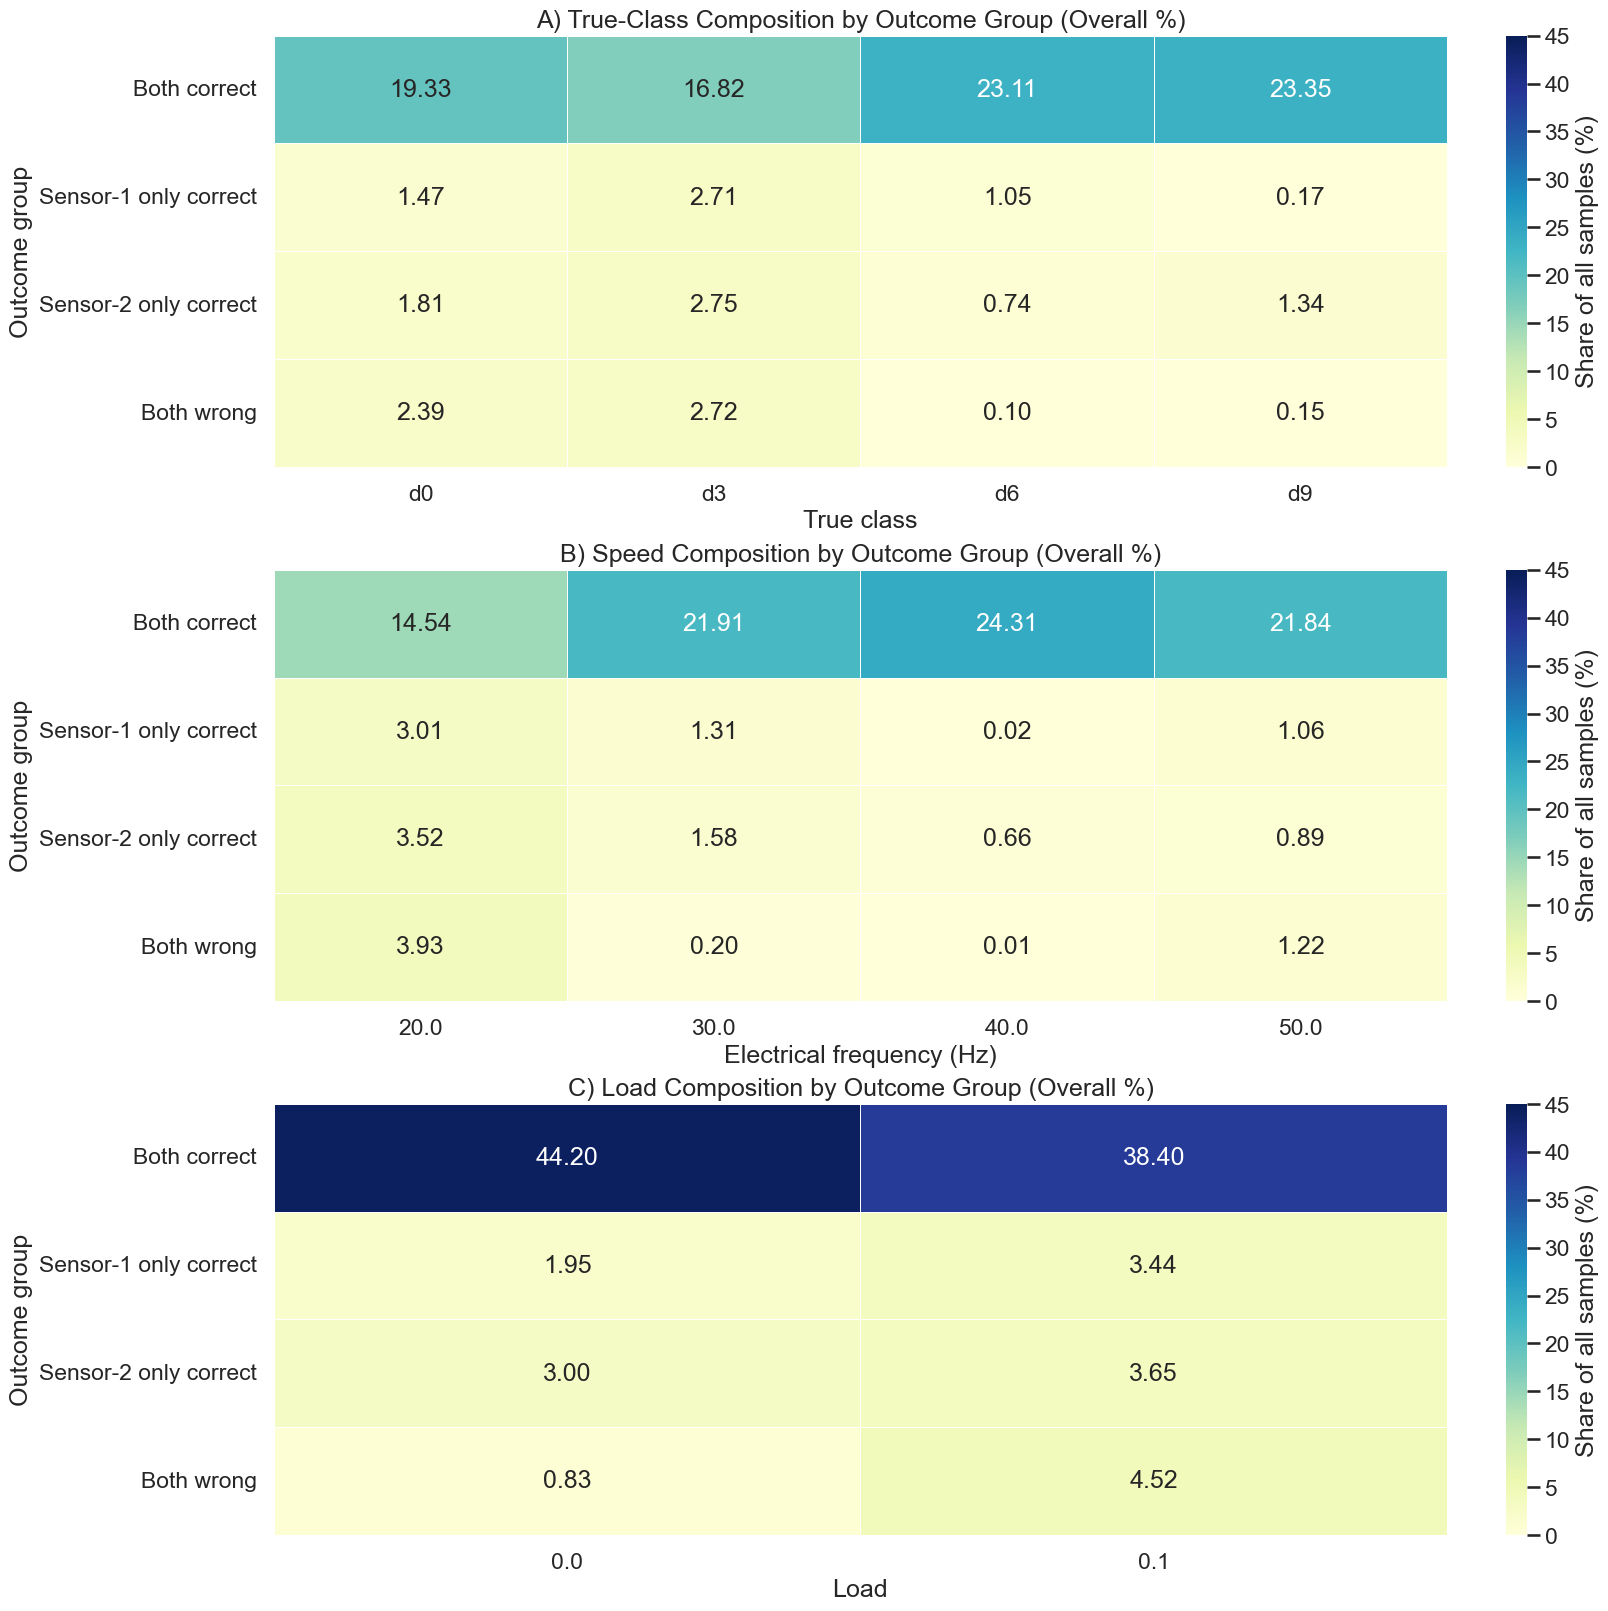

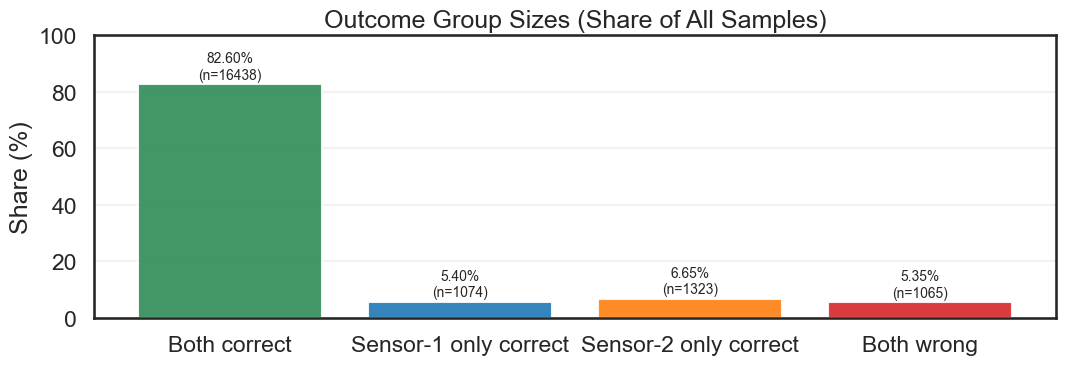

Stored overall-percentage pivots under disagreement_analysis['article_pivots_overall_pct'].


In [15]:
# Publication-style disagreement visuals (overall percentages, reader-friendly labels)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if "analysis_df" not in globals():
    raise RuntimeError("analysis_df is missing. Run Cell 7 first.")

if "disagreement_analysis" not in globals():
    disagreement_analysis = {}

plot_groups = [
    "both_correct",
    "sensor1_only_correct",
    "sensor2_only_correct",
    "both_wrong",
]

group_label_map = {
    "both_correct": "Both correct",
    "sensor1_only_correct": "Sensor-1 only correct",
    "sensor2_only_correct": "Sensor-2 only correct",
    "both_wrong": "Both wrong",
}

class_fixed_order = ["d0", "d3", "d6", "d9"]

def _overall_pct(df_counts: pd.DataFrame, n_total: int) -> pd.DataFrame:
    if n_total <= 0:
        return df_counts.astype(float) * 0.0
    return (df_counts.astype(float) / float(n_total)) * 100.0


def _ordered_class_columns(df: pd.DataFrame) -> list:
    present = df["true_class"].dropna().astype(str).unique().tolist()
    first = [c for c in class_fixed_order if c in present]
    rest = sorted(c for c in present if c not in class_fixed_order)
    return first + rest


def _ordered_speed_columns(df: pd.DataFrame) -> list:
    vals = pd.to_numeric(df["electrical_frequency_hz"], errors="coerce")
    return sorted(vals.dropna().unique().tolist())


def _ordered_load_columns(df: pd.DataFrame) -> list:
    raw_vals = df["load"].dropna().tolist()
    if len(raw_vals) == 0:
        return []
    as_series = pd.Series(raw_vals)
    numeric_vals = pd.to_numeric(as_series, errors="coerce")
    if numeric_vals.notna().all():
        return sorted(float(v) for v in numeric_vals.unique().tolist())

    semantic_priority = ["no load", "under load", "unknown"]
    as_str = as_series.astype(str)
    present = as_str.unique().tolist()
    first = [v for v in semantic_priority if v in present]
    rest = sorted(v for v in present if v not in semantic_priority)
    return first + rest


df_plot = analysis_df.copy()
df_plot["group"] = df_plot["group"].astype(str)

n_total_samples = int(df_plot.shape[0])
if n_total_samples == 0:
    raise ValueError("analysis_df has zero rows")

# Class composition as share of all samples.
class_cols = _ordered_class_columns(df_plot)
class_counts_all = (
    df_plot.groupby(["group", "true_class"], observed=False)
    .size()
    .unstack("true_class")
    .reindex(index=plot_groups, columns=class_cols)
    .fillna(0)
)
class_pct_overall = _overall_pct(class_counts_all, n_total_samples)

# Speed composition as share of all samples.
speed_cols = _ordered_speed_columns(df_plot)
speed_counts_all = (
    df_plot.groupby(["group", "electrical_frequency_hz"], observed=False)
    .size()
    .unstack("electrical_frequency_hz")
    .reindex(index=plot_groups, columns=speed_cols)
    .fillna(0)
)
speed_pct_overall = _overall_pct(speed_counts_all, n_total_samples)

# Load composition as share of all samples.
load_cols = _ordered_load_columns(df_plot)
load_counts_all = (
    df_plot.groupby(["group", "load"], observed=False)
    .size()
    .unstack("load")
    .reindex(index=plot_groups, columns=load_cols)
    .fillna(0)
)
load_pct_overall = _overall_pct(load_counts_all, n_total_samples)

# Replace internal group names with reader-friendly labels in plots.
plot_index_labels = [group_label_map.get(g, g) for g in plot_groups]
class_pct_plot = class_pct_overall.copy()
class_pct_plot.index = plot_index_labels
speed_pct_plot = speed_pct_overall.copy()
speed_pct_plot.index = plot_index_labels
load_pct_plot = load_pct_overall.copy()
load_pct_plot.index = plot_index_labels

sns.set_theme(style="white", context="talk")

vmax = float(
    max(
        class_pct_plot.to_numpy().max(initial=0.0),
        speed_pct_plot.to_numpy().max(initial=0.0),
        load_pct_plot.to_numpy().max(initial=0.0),
    )
)
vmax = max(1.0, np.ceil(vmax))

fig, axes = plt.subplots(3, 1, figsize=(16, 16), constrained_layout=True)

heatmap_kwargs = dict(
    cmap="YlGnBu",
    vmin=0,
    vmax=vmax,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Share of all samples (%)"},
)

sns.heatmap(class_pct_plot, ax=axes[0], annot=True, fmt=".2f", **heatmap_kwargs)
axes[0].set_title("A) True-Class Composition by Outcome Group (Overall %)")
axes[0].set_xlabel("True class")
axes[0].set_ylabel("Outcome group")
axes[0].tick_params(axis="x", rotation=0)

sns.heatmap(speed_pct_plot, ax=axes[1], annot=True, fmt=".2f", **heatmap_kwargs)
axes[1].set_title("B) Speed Composition by Outcome Group (Overall %)")
axes[1].set_xlabel("Electrical frequency (Hz)")
axes[1].set_ylabel("Outcome group")
axes[1].tick_params(axis="x", rotation=0)

sns.heatmap(load_pct_plot, ax=axes[2], annot=True, fmt=".2f", **heatmap_kwargs)
axes[2].set_title("C) Load Composition by Outcome Group (Overall %)")
axes[2].set_xlabel("Load")
axes[2].set_ylabel("Outcome group")
axes[2].tick_params(axis="x", rotation=0)

plt.show()

# Group-size context chart with friendly labels and overall percentages.
group_counts_all = (
    df_plot.groupby("group", observed=False)
    .size()
    .reindex(plot_groups)
    .fillna(0)
    .astype(int)
)
group_pct_all = _overall_pct(group_counts_all.to_frame("count"), n_total_samples)["count"]

fig, ax = plt.subplots(figsize=(11, 4))
bar_colors = ["#2E8B57", "#1f77b4", "#ff7f0e", "#d62728"]
bar_labels = [group_label_map.get(g, g) for g in plot_groups]
bars = ax.bar(bar_labels, group_pct_all.values, color=bar_colors, alpha=0.9)
ax.set_title("Outcome Group Sizes (Share of All Samples)")
ax.set_ylabel("Share (%)")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.25)

for b, pct, cnt in zip(bars, group_pct_all.values, group_counts_all.values):
    ax.text(
        b.get_x() + b.get_width() / 2,
        min(99.0, float(b.get_height()) + 1.0),
        f"{pct:.2f}%\n(n={int(cnt)})",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
plt.show()

# Persist prepared pivots for export/reuse.
disagreement_analysis["article_group_label_map"] = group_label_map
disagreement_analysis["article_pivots_overall_pct"] = {
    "class_pct": class_pct_overall,
    "speed_pct": speed_pct_overall,
    "load_pct": load_pct_overall,
}

print("Stored overall-percentage pivots under disagreement_analysis['article_pivots_overall_pct'].")